# Model-Based Feature Importance
ใช้โมเดลช่วยจัดอันดับ feature แล้วตรวจสอบว่าอันดับจาก model สอดคล้องกับ intuition, distribution analysis, statistical tests และ effect size หรือไม่

## Model Purpose
ส่วนนี้ใช้โมเดลช่วยจัดอันดับ feature แล้วเปรียบเทียบกับผลจาก data analysis เพื่อเช็คว่า model importance สอดคล้องกับ intuition และผลสถิติหรือไม่

## Model Performance And Alignment
เริ่มจากดูว่าโมเดลแยก churn ได้ดีแค่ไหน แล้วค่อยเช็คว่าความสำคัญของ feature จากโมเดลไปทางเดียวกับผลจาก data และสถิติหรือไม่

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style='whitegrid')

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')
df_importance = pd.read_csv('../../../Data/processed/feature_importance.csv', keep_default_na=False)
df_importance['importance_level'] = pd.Categorical(
    df_importance['importance_level'],
    categories=level_order,
    ordered=True
)
df_importance = df_importance.sort_values('importance', ascending=False).reset_index(drop=True)

features = [
    column for column in df.select_dtypes(include=['number']).columns
    if column != 'Churned'
]
X = df[features]
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

def rank_biserial_for_feature(feature):
    non_churn = df.loc[df['Churned'] == 0, feature].dropna()
    churn = df.loc[df['Churned'] == 1, feature].dropna()
    u_statistic, _ = mannwhitneyu(churn, non_churn, alternative='two-sided')
    auc_probability = u_statistic / (len(churn) * len(non_churn))
    return 2 * auc_probability - 1

rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

et_model = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
et_model.fit(X_train, y_train)
et_auc = roc_auc_score(y_test, et_model.predict_proba(X_test)[:, 1])

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

model_importance_df = pd.DataFrame({
    'feature': features,
    'rf_importance': rf_model.feature_importances_,
    'extra_trees_importance': et_model.feature_importances_,
    'permutation_importance': perm_result.importances_mean,
    'rank_biserial': [rank_biserial_for_feature(feature) for feature in features]
})

if xgb_available:
    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    model_importance_df['xgb_importance'] = xgb_model.feature_importances_
    xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
else:
    xgb_auc = np.nan

comparison_df = df_importance.merge(model_importance_df, on='feature', how='left')
comparison_df['abs_rank_biserial'] = comparison_df['rank_biserial'].abs()
comparison_df['reference_rank'] = comparison_df['importance'].rank(ascending=False, method='min')
comparison_df['rf_rank'] = comparison_df['rf_importance'].rank(ascending=False, method='min')
comparison_df['extra_trees_rank'] = comparison_df['extra_trees_importance'].rank(ascending=False, method='min')
comparison_df['permutation_rank'] = comparison_df['permutation_importance'].rank(ascending=False, method='min')
comparison_df['effect_rank'] = comparison_df['abs_rank_biserial'].rank(ascending=False, method='min')

rank_columns = ['rf_rank', 'extra_trees_rank', 'permutation_rank', 'effect_rank']
if xgb_available:
    comparison_df['xgb_rank'] = comparison_df['xgb_importance'].rank(ascending=False, method='min')
    rank_columns.append('xgb_rank')

comparison_df['consensus_rank'] = comparison_df[rank_columns].mean(axis=1)
comparison_df = comparison_df.sort_values('consensus_rank').reset_index(drop=True)

In [3]:
model_performance = pd.DataFrame({
    'model': ['Random Forest', 'Extra Trees', 'XGBoost'],
    'test_auc': [rf_auc, et_auc, xgb_auc]
})

reference_vs_rf = spearmanr(comparison_df['importance'], comparison_df['rf_importance'])
reference_vs_effect = spearmanr(comparison_df['importance'], comparison_df['abs_rank_biserial'])
rf_vs_effect = spearmanr(comparison_df['rf_importance'], comparison_df['abs_rank_biserial'])

alignment_summary = pd.DataFrame({
    'comparison': [
        'Reference importance vs Random Forest',
        'Reference importance vs Effect size',
        'Random Forest vs Effect size'
    ],
    'spearman_correlation': [
        reference_vs_rf.statistic,
        reference_vs_effect.statistic,
        rf_vs_effect.statistic
    ],
    'p_value': [
        reference_vs_rf.pvalue,
        reference_vs_effect.pvalue,
        rf_vs_effect.pvalue
    ]
})

## Feature Agreement Check
ถ้า feature ใดติด top rank ทั้งจาก model importance และ effect size แปลว่า data กับ model สอดคล้องกันสูง และสามารถใช้เล่า insight ได้มั่นใจขึ้น

,model,test_auc
0,Random Forest,0.926243
1,Extra Trees,0.918871
2,XGBoost,NaN


,comparison,spearman_correlation,p_value
0,Reference importance vs Random Forest,0.997,3.5516e-23
1,Reference importance vs Effect size,0.294,1.9659e-01
2,Random Forest vs Effect size,0.313,1.6714e-01


,feature,importance_level,importance,rf_importance,extra_trees_importance,permutation_importance,abs_rank_biserial,consensus_rank
0,Customer_Service_Calls,Strong,0.1279,0.1252,0.0987,0.1159,0.378,1.50
1,Cart_Abandonment_Rate,Strong,0.0991,0.1025,0.0874,0.0554,0.356,2.75
2,Lifetime_Value,Strong,0.1290,0.1358,0.0924,0.1178,0.070,5.50
3,Email_Open_Rate,Moderate,0.0473,0.0476,0.0506,0.0218,0.287,6.25
4,Age,Strong,0.0685,0.0674,0.0594,0.0494,0.126,7.00
5,Days_Since_Last_Purchase,Strong,0.0609,0.0606,0.0584,0.0345,0.165,7.75
6,Discount_Usage_Rate,Strong,0.0715,0.0704,0.0485,0.0403,0.103,8.00
7,Pages_Per_Session,Moderate,0.0406,0.0375,0.0452,0.0048,0.290,8.50
8,Session_Duration_Avg,Moderate,0.0408,0.0403,0.0444,0.0052,0.280,8.75
9,Total_Purchases,Moderate,0.0556,0.0543,0.0420,0.0066,0.239,9.50


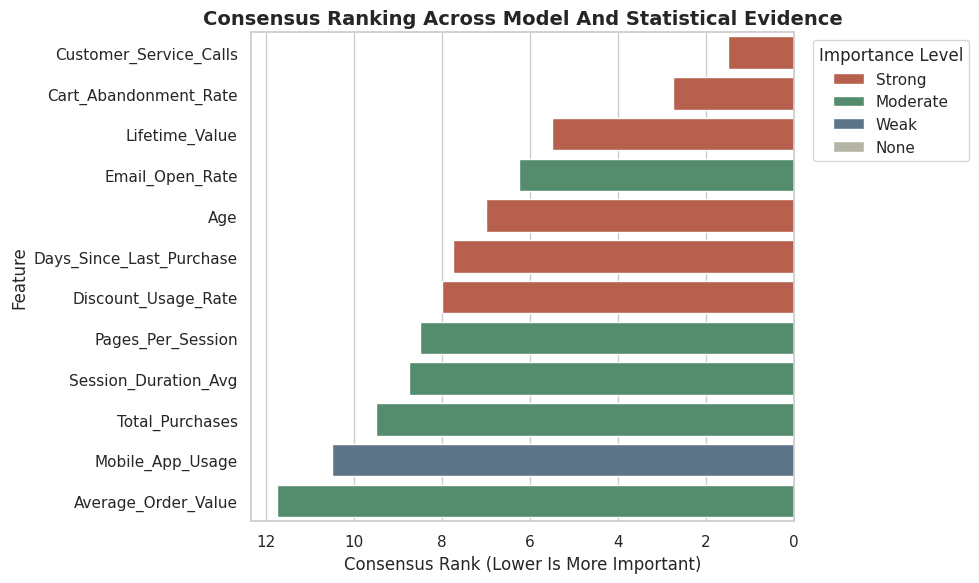

In [4]:
display(model_performance)
display(
    alignment_summary.assign(
        spearman_correlation=alignment_summary['spearman_correlation'].round(3),
        p_value=alignment_summary['p_value'].map(lambda value: f'{value:.4e}')
    )
)

comparison_display = comparison_df.assign(
    importance=comparison_df['importance'].round(4),
    rf_importance=comparison_df['rf_importance'].round(4),
    extra_trees_importance=comparison_df['extra_trees_importance'].round(4),
    permutation_importance=comparison_df['permutation_importance'].round(4),
    abs_rank_biserial=comparison_df['abs_rank_biserial'].round(3),
    consensus_rank=comparison_df['consensus_rank'].round(2)
)

columns_to_show = [
    'feature', 'importance_level', 'importance', 'rf_importance', 'extra_trees_importance',
    'permutation_importance', 'abs_rank_biserial', 'consensus_rank'
]
if xgb_available:
    comparison_display['xgb_importance'] = comparison_df['xgb_importance'].round(4)
    columns_to_show.insert(5, 'xgb_importance')

display(comparison_display[columns_to_show].head(15))

plt.figure(figsize=(10, 6))
plot_df = comparison_df.nsmallest(12, 'consensus_rank').copy()
sns.barplot(
    data=plot_df,
    y='feature',
    x='consensus_rank',
    hue='importance_level',
    dodge=False,
    palette=palette_level
)
plt.gca().invert_xaxis()
plt.title('Consensus Ranking Across Model And Statistical Evidence', fontsize=14, weight='bold')
plt.xlabel('Consensus Rank (Lower Is More Important)')
plt.ylabel('Feature')
plt.legend(title='Importance Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
top_consensus = comparison_df.nsmallest(10, 'consensus_rank')[['feature', 'importance_level', 'consensus_rank']].copy()
display(top_consensus)

print('Alignment interpretation:')
print('- High correlation means model ranking and data evidence point in the same direction.')
print('- Features that stay near the top across RF, Extra Trees, permutation importance, and effect size are the most trustworthy.')
if xgb_available:
    print('- XGBoost is included in the consensus ranking.')
else:
    print('- XGBoost is not installed in this environment, so the notebook falls back to Random Forest + Extra Trees + permutation importance.')

comparison_df.to_csv('../../../Data/processed/model_feature_alignment.csv', index=False)
print('Saved model alignment summary to Data/processed/model_feature_alignment.csv')

,feature,importance_level,consensus_rank
0,Customer_Service_Calls,Strong,1.50
1,Cart_Abandonment_Rate,Strong,2.75
2,Lifetime_Value,Strong,5.50
3,Email_Open_Rate,Moderate,6.25
4,Age,Strong,7.00
5,Days_Since_Last_Purchase,Strong,7.75
6,Discount_Usage_Rate,Strong,8.00
7,Pages_Per_Session,Moderate,8.50
8,Session_Duration_Avg,Moderate,8.75
9,Total_Purchases,Moderate,9.50


Alignment interpretation:
- High correlation means model ranking and data evidence point in the same direction.
- Features that stay near the top across RF, Extra Trees, permutation importance, and effect size are the most trustworthy.
- XGBoost is not installed in this environment, so the notebook falls back to Random Forest + Extra Trees + permutation importance.
Saved model alignment summary to Data/processed/model_feature_alignment.csv
